# LAS-Mamba-GNN Training Notebook



## Setup

In [ ]:
import sys
import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import random
from tqdm import tqdm

# Find project root - works in Jupyter and script
cwd = Path.cwd()

possible_roots = [
    cwd,
    cwd / "notebooks",
    cwd / "..",
    cwd / ".." / "notebooks",
]

for root in possible_roots:
    if (root / "data").exists() and (root / "src").exists():
        ROOT_DIR = root
        break
else:
    for parent in [cwd] + list(cwd.parents):
        if (parent / "data").exists() and (parent / "src").exists():
            ROOT_DIR = parent
            break
    else:
        ROOT_DIR = cwd

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

os.chdir(ROOT_DIR)
print(f"Working directory: {os.getcwd()}")

from src.dataset.elliptic_dataset import FastEllipticDataset
from src.models.mamba_gnn import create_mamba_gnn
from src.models.loss import get_loss_function
from src.utils.config import MODEL_CONFIG, TRAINING_CONFIG, LOSS_CONFIG
from src.utils.metrics import compute_metrics
from src.utils.graph_utils import get_neighbor_subgraph

print(f"   Root directory: {ROOT_DIR}")
print(f"   PyTorch version: {torch.__version__}")
print(f"   CUDA available: {torch.cuda.is_available()}")

Working directory: d:\Capstone\aml-elliptic2-detection-main
   Root directory: d:\Capstone\aml-elliptic2-detection-main\notebooks\..
   PyTorch version: 2.5.1+cu121
   CUDA available: True


## Configuration

In [ ]:
# Training configuration
CONFIG = {
    # Data paths
    'graph_dir': 'data/processed/graph',
    'sequences_dir': 'data/processed/sequences',
    'index_dir': 'data/processed/index',

    # Model
    'use_gnn': True,
    'use_mamba': True,

    # Training
    'device': 'auto',
    'batch_size': 192,
    'num_epochs': 120,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'num_workers': 4,
    'use_amp': True,
    'use_compile': False,

    # Scheduler
    'use_scheduler': True,
    'scheduler_type': 'reduce_on_plateau',
    'scheduler_patience': 4,
    'scheduler_factor': 0.5,
    'min_lr': 1e-7,

    # Loss / threshold tuning
    'loss_type': 'focal',
    'class_weights': [1.0, 50.0],
    'threshold': 0.35,
    'focal_gamma': 2.0,
    'focal_alpha': 0.5,

    # Early stopping
    'early_stopping_patience': 20,
    'early_stopping_metric': 'auc_pr',
    'val_interval': 1,

    # Reproducibility
    'seed': 42,
}


def set_seed(seed):
    """Set random seed with fast CUDA defaults for training."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(CONFIG['seed'])


## Load Dataset

In [3]:
print("Loading datasets")

train_dataset = FastEllipticDataset(
    graph_dir=CONFIG['graph_dir'],
    sequences_dir=CONFIG['sequences_dir'],
    index_dir=CONFIG['index_dir'],
    split='train'
)

val_dataset = FastEllipticDataset(
    graph_dir=CONFIG['graph_dir'],
    sequences_dir=CONFIG['sequences_dir'],
    index_dir=CONFIG['index_dir'],
    split='val'
)

test_dataset = FastEllipticDataset(
    graph_dir=CONFIG['graph_dir'],
    sequences_dir=CONFIG['sequences_dir'],
    index_dir=CONFIG['index_dir'],
    split='test'
)

print(f"   Train: {len(train_dataset):,}")
print(f"   Val:   {len(val_dataset):,}")
print(f"   Test:  {len(test_dataset):,}")

Loading datasets
Loading graph structure...
  Graph: 444,521 nodes, 734,274 edges
Loading labels from cache...
  Loaded 10466 suspicious / 434055 licit
  Split 'train': 311,164 samples
Loading graph structure...
  Graph: 444,521 nodes, 734,274 edges
Loading labels from cache...
  Loaded 10466 suspicious / 434055 licit
  Split 'val': 66,678 samples
Loading graph structure...
  Graph: 444,521 nodes, 734,274 edges
Loading labels from cache...
  Loaded 10466 suspicious / 434055 licit
  Split 'test': 66,679 samples
   Train: 311,164
   Val:   66,678
   Test:  66,679


## Create DataLoaders

In [4]:
from torch.utils.data import DataLoader

if CONFIG['device'] == 'auto':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
else:
    device = torch.device(CONFIG['device'])

print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision('medium')

num_workers = CONFIG['num_workers']

loader_kwargs = {
    'num_workers': num_workers,
    'pin_memory': device.type == 'cuda',
    'collate_fn': FastEllipticDataset.collate_fn,
}
if num_workers > 0:
    loader_kwargs['persistent_workers'] = True
    loader_kwargs['prefetch_factor'] = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    **loader_kwargs
)

edge_index = train_dataset.edge_index.to(device)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader):,}")
print(f"  Val batches:   {len(val_loader):,}")
print(f"  Test batches:  {len(test_loader):,}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
DataLoaders created:
  Train batches: 1,621
  Val batches:   348
  Test batches:  348


## Create Model

In [ ]:
# Create model
model_params = {
    **MODEL_CONFIG,
    'use_gnn': CONFIG['use_gnn'],
    'use_mamba': CONFIG['use_mamba'],
    'mamba_pooling': CONFIG.get('mamba_pooling', 'mean'), 
    'dropout': CONFIG.get('dropout', 0.3)
}

 # 2. Khởi tạo mô hình Mamba-GNN
model = create_mamba_gnn(model_params).to(device)

compile_enabled = False
if device.type == 'cuda' and CONFIG.get('use_compile', False):
    try:
        model = torch.compile(model)
        compile_enabled = True
    except Exception as e:
        print(f"torch.compile skipped: {e}")

num_params = sum(p.numel() for p in model.parameters())
print("Model created:")
print(f"  Parameters: {num_params:,}")
print(f"  Using GNN: {CONFIG['use_gnn']}")
print(f"  Using Mamba: {CONFIG['use_mamba']}")
print(f"  Compile enabled: {compile_enabled}")

## Create Optimizer and Loss

In [6]:
class_weights = torch.tensor(CONFIG['class_weights'], dtype=torch.float32, device=device)
criterion = get_loss_function(
    loss_type=CONFIG['loss_type'],
    class_weights=class_weights,
    focal_gamma=CONFIG['focal_gamma']
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

if CONFIG.get('use_scheduler', True):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=CONFIG['scheduler_factor'],
        patience=CONFIG['scheduler_patience'],
        min_lr=CONFIG['min_lr']
    )
else:
    scheduler = None

use_amp = bool(CONFIG.get('use_amp', True) and device.type == 'cuda')
scaler = torch.amp.GradScaler('cuda') if use_amp else None

print("Optimizer and Loss created:")
print(f"  Loss type: {CONFIG['loss_type']}")
print(f"  Class weights: {CONFIG['class_weights']}")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  AMP enabled: {use_amp}")

Optimizer and Loss created:
  Loss type: focal
  Class weights: [1.0, 50.0]
  Learning rate: 0.0001
  AMP enabled: True


## Training Functions

In [ ]:
def _prepare_node_features(sequences):
    """Tạo đặc trưng 576 chiều đúng chuẩn cho input_adapter"""
    node_feat_list = []
    for flow_idx in [0, 1]: # in_flow và out_flow
        flow_data = sequences[:, flow_idx] # [N, 50, 96]
        node_feat_list.append(flow_data.mean(dim=1))
        node_feat_list.append(flow_data.max(dim=1)[0])
        node_feat_list.append(flow_data[:, -1, :])
    return torch.cat(node_feat_list, dim=1) # Trả về [N, 576]

def train_epoch(
    model,
    loader,
    dataset,      # Cần thêm dataset để load lân cận
    edge_index,
    criterion,
    optimizer,
    device,
    num_hops=1,   # Thêm tham số mở rộng đồ thị
    scaler=None,
    use_amp=False,
    use_gnn=True,
    grad_clip_norm=0.5,
):
    """Huấn luyện 1 epoch với Neighbor Expansion và Mamba-GNN"""
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch_idx, (sequences, labels, batch_global_indices) in enumerate(loader):
        batch_global_indices = batch_global_indices.to(device)
        labels = labels.to(device)

        if use_gnn and edge_index is not None:
            # 1. Neighbor Expansion (Lấy thêm các node lân cận)
            subset, local_edge_index, mapping = get_neighbor_subgraph(
                edge_index, batch_global_indices, num_hops=num_hops
            )
            local_edge_index = local_edge_index.to(device)

             # 2. Load chuỗi giao dịch cho TOÀN BỘ subgraph mở rộng
            all_sequences, _ = dataset.get_batch(subset.tolist())
            all_sequences = all_sequences.to(device)

            # 3. Tạo đặc trưng 576 chiều
            all_node_features = _prepare_node_features(all_sequences)

            optimizer.zero_grad(set_to_none=True)

            if use_amp and scaler is not None:
                with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                    all_logits = model(all_node_features, all_sequences, local_edge_index)
                    logits = all_logits[mapping] # Chỉ lấy kết quả của các node trong batch gốc
                    loss = criterion(logits, labels)
    
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
                scaler.step(optimizer)
                scaler.update()
            else:
                all_logits = model(all_node_features, all_sequences, local_edge_index)
                logits = all_logits[mapping]
                loss = criterion(logits, labels)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
                optimizer.step()



        total_loss += loss.item()
        num_batches += 1
        if batch_idx % 200 == 0:
            print(f"  Batch {batch_idx}/{len(loader)}, Loss: {loss.item():.4f}")

    return total_loss / num_batches if num_batches > 0 else 0.0


def evaluate(model, loader, dataset, edge_index, criterion, device,
use_gnn=True, threshold=0.35, search_threshold=False, num_hops=1):
    """Đánh giá mô hình với Neighbor Expansion"""
    model.eval()
    all_probs, all_labels = [], []
    total_loss, num_batches = 0.0, 0
    
    with torch.no_grad():
        for sequences, labels, batch_global_indices in loader:
            batch_global_indices = batch_global_indices.to(device)
            labels = labels.to(device)

            if use_gnn and edge_index is not None:
                subset, local_edge_index, mapping = get_neighbor_subgraph(
                    edge_index, batch_global_indices, num_hops=num_hops
                )
                local_edge_index = local_edge_index.to(device)
                all_sequences, _ = dataset.get_batch(subset.tolist())
                all_sequences = all_sequences.to(device)
                all_node_features = _prepare_node_features(all_sequences)

                all_logits = model(all_node_features, all_sequences, local_edge_index)
                logits = all_logits[mapping]
            else:
                sequences = sequences.to(device)
                node_features = _prepare_node_features(sequences)
                logits = model(node_features, sequences, torch.empty((2, 0), dtype=torch.long, device=device))

            loss_val = criterion(logits, labels)
            total_loss += loss_val.item()
            num_batches += 1

            all_probs.append(torch.softmax(logits, dim=1)[:, 1].cpu())
            all_labels.append(labels.cpu())

    y_true = torch.cat(all_labels)
    y_prob = torch.cat(all_probs)

    best_threshold = threshold
    if search_threshold:
        best_f1 = -1.0
        for t in np.arange(0.1, 0.9, 0.05):
            y_pred_t = (y_prob > t).long()
            m = compute_metrics(y_true, y_pred_t, y_prob)
            if m['f1'] > best_f1:
                best_f1 = m['f1']
                best_threshold = float(t)

    y_pred = (y_prob > best_threshold).long()
    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics['threshold'] = best_threshold
    metrics['loss'] = total_loss / num_batches
    return metrics

## Training Loop

In [8]:
from pathlib import Path
import time

# Create checkpoint directory
checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_f1': [],
    'val_auc_pr': [],
    'val_auc_roc': [],
    'val_recall': [],
    'val_precision': [],
    'val_threshold': []
}

# Early stopping setup
best_metric_name = CONFIG.get('early_stopping_metric', 'auc_pr')
best_val_metric = -1.0
best_val_f1 = 0.0
best_threshold = CONFIG['threshold']
patience_counter = 0

print("Starting training")
start_time = time.time()

for epoch in range(1, CONFIG['num_epochs'] + 1):
    epoch_start = time.time()

    train_loss = train_epoch(
        model,
        train_loader,
        edge_index,
        criterion,
        optimizer,
        device,
        scaler=scaler,
        use_amp=use_amp,
        use_gnn=CONFIG['use_gnn'],
    )

    if epoch % CONFIG['val_interval'] == 0:
        val_metrics = evaluate(
            model,
            val_loader,
            edge_index,
            criterion,
            device,
            use_gnn=CONFIG['use_gnn'],
            threshold=best_threshold,
            search_threshold=True,
        )

        best_threshold = val_metrics['threshold']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc_pr'].append(val_metrics.get('auc_pr', 0.0))
        history['val_auc_roc'].append(val_metrics.get('auc_roc', 0.0))
        history['val_recall'].append(val_metrics['recall'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_threshold'].append(best_threshold)

        if scheduler is not None:
            scheduler_metric = val_metrics.get(best_metric_name, val_metrics['f1'])
            scheduler.step(scheduler_metric)

        epoch_time = time.time() - epoch_start
        current_metric = val_metrics.get(best_metric_name, val_metrics['f1'])
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"val_auc_pr={val_metrics.get('auc_pr', 0.0):.4f} | "
            f"thr={best_threshold:.2f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e} | "
            f"time={epoch_time:.1f}s"
        )

        if current_metric > best_val_metric:
            best_val_metric = current_metric
            best_val_f1 = val_metrics['f1']
            patience_counter = 0

            checkpoint_path = checkpoint_dir / 'best_model.pt'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_metrics': val_metrics,
                'best_threshold': best_threshold,
                'config': CONFIG,
            }, checkpoint_path)
            print(f"  -> Saved best model ({best_metric_name}={best_val_metric:.4f}, f1={best_val_f1:.4f})")
        else:
            patience_counter += 1

        if patience_counter >= CONFIG['early_stopping_patience']:
            print(f"\nEarly stopping at epoch {epoch}")
            break
    else:
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f}")

total_time = time.time() - start_time
print(f"Training completed in {total_time/60:.1f} minutes")
print(f"Best {best_metric_name}: {best_val_metric:.4f}")
print(f"Best val_f1: {best_val_f1:.4f}")
print(f"Best threshold: {best_threshold:.2f}")


Starting training
  Batch 0/1621, Loss: 0.7779
  Batch 200/1621, Loss: 0.4320
  Batch 400/1621, Loss: 0.3172
  Batch 600/1621, Loss: 0.4042
  Batch 800/1621, Loss: 0.4172
  Batch 1000/1621, Loss: 0.2354
  Batch 1200/1621, Loss: 0.3069
  Batch 1400/1621, Loss: 0.3984
  Batch 1600/1621, Loss: 0.4279
Epoch 001 | train_loss=0.3689 | val_loss=0.3433 | val_f1=0.0627 | val_auc_pr=0.0787 | thr=0.50 | lr=1.00e-04 | time=798.3s
  -> Saved best model (auc_pr=0.0787, f1=0.0627)
  Batch 0/1621, Loss: 0.4871
  Batch 200/1621, Loss: 0.4428
  Batch 400/1621, Loss: 0.2763
  Batch 600/1621, Loss: 0.2235
  Batch 800/1621, Loss: 0.2770
  Batch 1000/1621, Loss: 0.4589
  Batch 1200/1621, Loss: 0.1940
  Batch 1400/1621, Loss: 0.4241
  Batch 1600/1621, Loss: 0.4139
Epoch 002 | train_loss=0.3396 | val_loss=0.3278 | val_f1=0.1754 | val_auc_pr=0.1399 | thr=0.60 | lr=1.00e-04 | time=864.9s
  -> Saved best model (auc_pr=0.1399, f1=0.1754)
  Batch 0/1621, Loss: 0.3072
  Batch 200/1621, Loss: 0.3088
  Batch 400/1621

## Evaluate on Test Set

In [9]:
# Load best model
checkpoint_path = checkpoint_dir / 'best_model.pt'
if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    best_threshold = checkpoint.get('best_threshold', CONFIG['threshold'])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")
    print(f"Using threshold: {best_threshold:.2f}")

    # Evaluate on test set
    print("\nEvaluating on test set...")
    test_metrics = evaluate(
        model,
        test_loader,
        edge_index,
        criterion,
        device,
        use_gnn=CONFIG['use_gnn'],
        threshold=best_threshold,
        search_threshold=False,
    )

    print("TEST SET RESULTS")
    print(f"Loss:      {test_metrics['loss']:.4f}")
    print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"Precision: {test_metrics['precision']:.4f}")
    print(f"Recall:    {test_metrics['recall']:.4f}")
    print(f"F1:        {test_metrics['f1']:.4f}")
    print(f"AUC-ROC:   {test_metrics.get('auc_roc', 0.0):.4f}")
    print(f"AUC-PR:    {test_metrics.get('auc_pr', 0.0):.4f}")
else:
    print("No checkpoint found!")

C:\Users\Admin\AppData\Local\Temp\ipykernel_26776\3991404491.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

Loaded best model from epoch 119
Using threshold: 0.75

Evaluating on test set...
TEST SET RESULTS
Loss:      0.2953
Accuracy:  0.9772
Precision: 0.5474
Recall:    0.1911
F1:        0.2833
AUC-ROC:   0.8240
AUC-PR:    0.2679


## Plot Training History

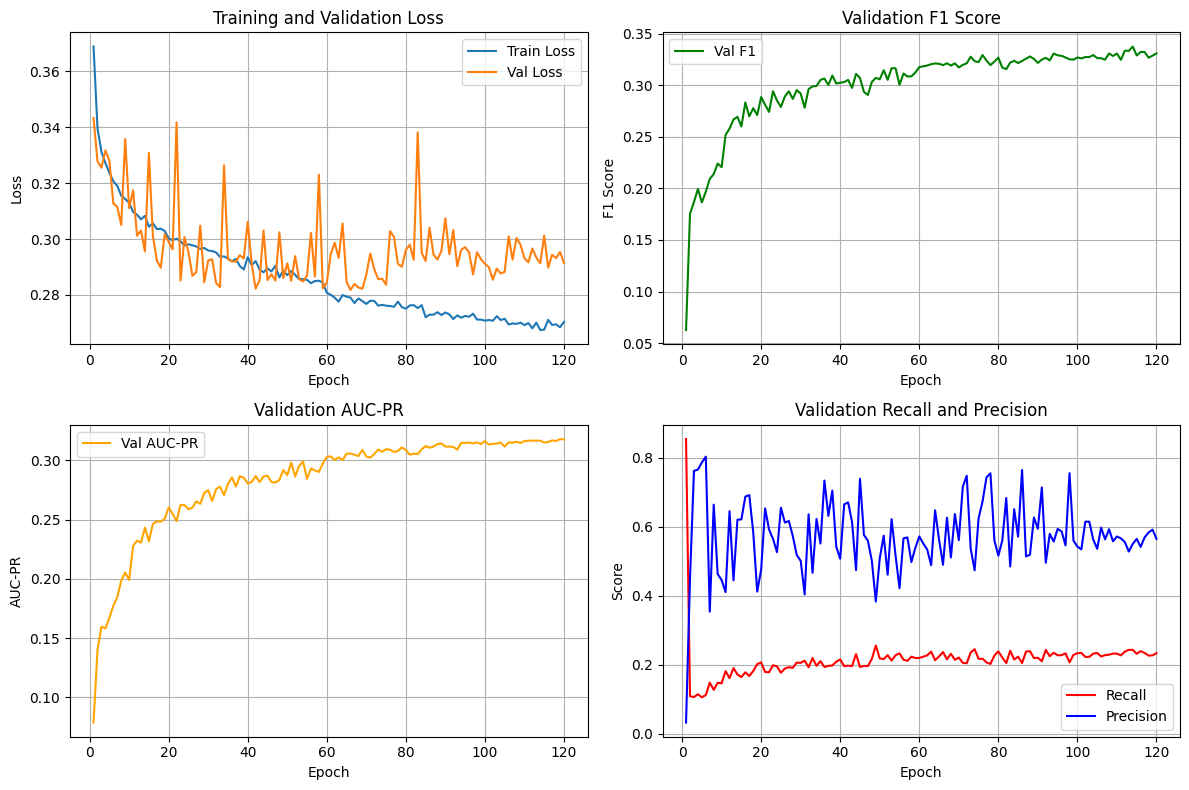

Training history plot saved to 'training_history.png'


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

epochs_range = range(1, len(history['train_loss']) + 1)

# Plot Loss
axes[0, 0].plot(epochs_range, history['train_loss'], label='Train Loss')
if history['val_loss']:
    axes[0, 0].plot(epochs_range, history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot F1
if history['val_f1']:
    axes[0, 1].plot(epochs_range, history['val_f1'], label='Val F1', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].set_title('Validation F1 Score')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot AUC-PR
if history['val_auc_pr']:
    axes[1, 0].plot(epochs_range, history['val_auc_pr'], label='Val AUC-PR', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC-PR')
axes[1, 0].set_title('Validation AUC-PR')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot Recall and Precision
if history['val_recall']:
    axes[1, 1].plot(epochs_range, history['val_recall'], label='Recall', color='red')
if history['val_precision']:
    axes[1, 1].plot(epochs_range, history['val_precision'], label='Precision', color='blue')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Validation Recall and Precision')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

print("Training history plot saved to 'training_history.png'")